In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Install required library
!pip install segmentation-models-pytorch

# Imports
import os
import json
import numpy as np
import cv2
import torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.0 MB/s eta 0:00:0000:01


## Checking how the data looks for each image


In [3]:
# Paths (change if needed)
image_path = "/kaggle/input/datasets/gouravanirudh/fashion/processed/train/images/000019.jpg"
anno_path = "/kaggle/input/datasets/gouravanirudh/fashion/processed/train/annos/000019.json"

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Load annotation
with open(anno_path) as f:
    data = json.load(f)

# Print basic info
print("Image shape:", image.shape)
print("\nAnnotation keys:", data.keys())

# Extract items
items = []
for key in data:
    if key.startswith("item"):
        items.append(data[key])

print("\nNumber of items:", len(items))

# Print one sample item
print("\nSample item:")
print(items[0])

Image shape: (1125, 750, 3)

Annotation keys: dict_keys(['item2', 'source', 'pair_id', 'item1'])

Number of items: 2

Sample item:
{'segmentation': [[365, 803, 453, 802, 537, 808, 584, 851, 607, 911, 435, 891, 307, 815, 343, 801, 365, 803]], 'scale': 1, 'viewpoint': 2, 'zoom_in': 1, 'landmarks': [365, 803, 1, 453, 802, 1, 537, 808, 1, 343, 801, 1, 307, 815, 1, 435, 891, 2, 607, 911, 2, 584, 851, 2], 'style': 0, 'bounding_box': [276, 799, 611, 949], 'category_id': 9, 'occlusion': 3, 'category_name': 'skirt'}


## Visuallization of the srgmentation borders

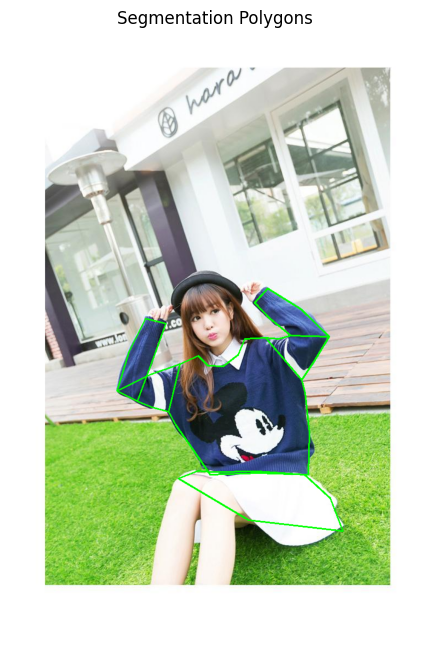

In [4]:
import matplotlib.pyplot as plt

# Function to draw polygons
def draw_polygons(image, items):
    img_copy = image.copy()

    for item in items:
        if "segmentation" in item:
            for poly in item["segmentation"]:
                pts = np.array(poly).reshape(-1, 2).astype(np.int32)
                cv2.polylines(img_copy, [pts], isClosed=True, color=(0,255,0), thickness=2)

    return img_copy


# Draw polygons
vis_img = draw_polygons(image, items)

# Show image
plt.figure(figsize=(6,8))
plt.imshow(vis_img)
plt.axis("off")
plt.title("Segmentation Polygons")
plt.show()

In [5]:
def polygon_to_mask(polygons, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)

    for poly in polygons:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)

    return mask

### only Item Binary Mask put

(np.float64(-0.5), np.float64(749.5), np.float64(1124.5), np.float64(-0.5))

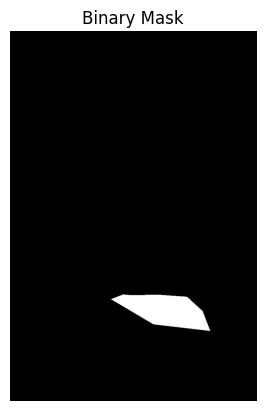

In [6]:
# Take first item
item = items[0]

mask = polygon_to_mask(item["segmentation"], image.shape[0], image.shape[1])

plt.imshow(mask, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

### all Items Combined Binary Mask

(np.float64(-0.5), np.float64(749.5), np.float64(1124.5), np.float64(-0.5))

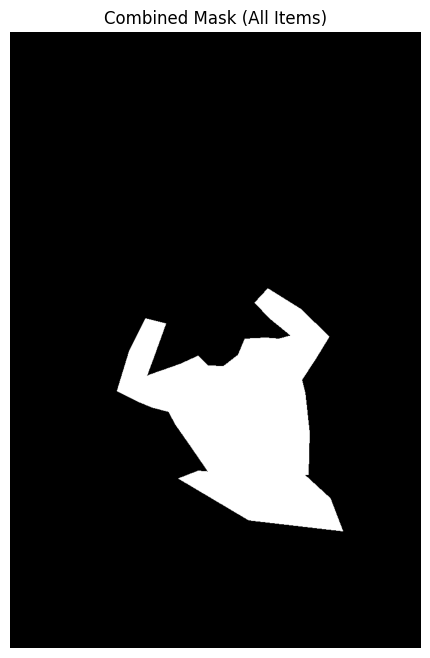

In [7]:
combined_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

for item in items:
    if "segmentation" in item:
        poly_mask = polygon_to_mask(item["segmentation"], image.shape[0], image.shape[1])
        
        # Assign a temporary value (we'll fix classes later)
        combined_mask[poly_mask == 1] = 1

# Visualize
plt.figure(figsize=(6,8))
plt.imshow(combined_mask, cmap='gray')
plt.title("Combined Mask (All Items)")
plt.axis("off")

### Overlayed Mask Just for visulaization

(np.float64(-0.5), np.float64(749.5), np.float64(1124.5), np.float64(-0.5))

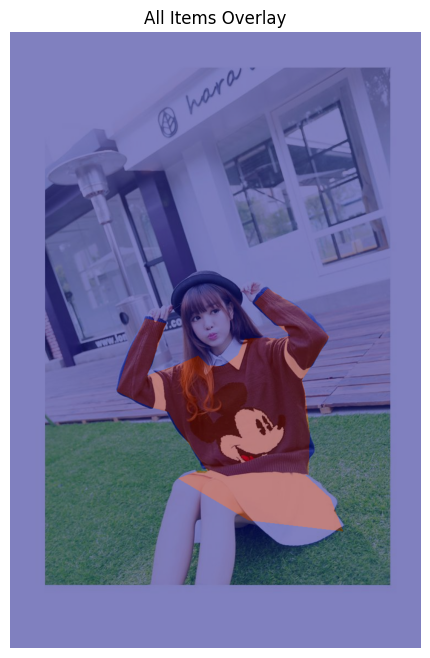

In [8]:
plt.figure(figsize=(6,8))
plt.imshow(image)
plt.imshow(combined_mask, alpha=0.5, cmap='jet')
plt.title("All Items Overlay")
plt.axis("off")

In [9]:
category_map = {
    1:1,   # short sleeve top
    2:2,   # long sleeve top
    7:3,   # shorts
    8:4,   # trousers
    9:5    # skirt
}


In [10]:
multi_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)

for item in items:
    cat_id = item["category_id"]

    if cat_id not in category_map:
        continue

    class_id = category_map[cat_id]

    if "segmentation" in item:
        poly_mask = polygon_to_mask(item["segmentation"], image.shape[0], image.shape[1])
        multi_mask[poly_mask == 1] = class_id

(np.float64(-0.5), np.float64(749.5), np.float64(1124.5), np.float64(-0.5))

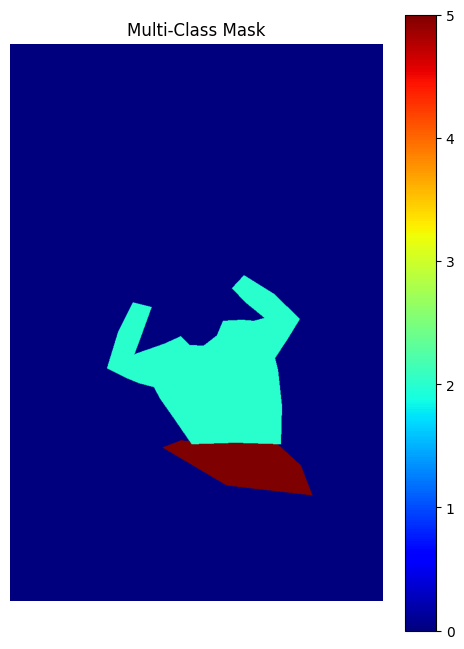

In [11]:
plt.figure(figsize=(6,8))
plt.imshow(multi_mask, cmap='jet')
plt.colorbar()
plt.title("Multi-Class Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(749.5), np.float64(1124.5), np.float64(-0.5))

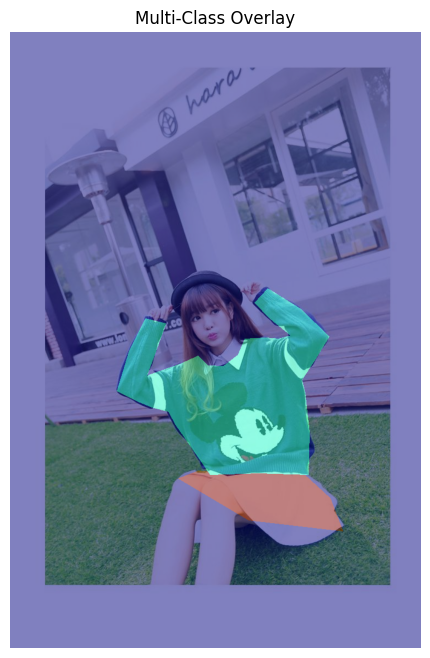

In [12]:
plt.figure(figsize=(6,8))
plt.imshow(image)
plt.imshow(multi_mask, alpha=0.5, cmap='jet')
plt.title("Multi-Class Overlay")
plt.axis("off")

In [13]:
from torch.utils.data import Dataset

class FashionDataset(Dataset):
    def __init__(self, image_dir, annotation_dir, category_map):
        self.image_dir = image_dir
        self.annotation_dir = annotation_dir
        self.files = os.listdir(image_dir)
        self.category_map = category_map

    def __len__(self):
        return len(self.files)

    def polygon_to_mask(self, polygons, height, width):
        mask = np.zeros((height, width), dtype=np.uint8)
        for poly in polygons:
            pts = np.array(poly).reshape(-1, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 1)
        return mask

    def __getitem__(self, idx):
        file_name = self.files[idx]

        # ---- Load Image ----
        img_path = os.path.join(self.image_dir, file_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # ✅ CHANGE 1: Store original size BEFORE resizing
        orig_h, orig_w = image.shape[:2]

        # ---- Resize Image ----
        image = cv2.resize(image, (256, 256))
        new_h, new_w = 256, 256

        # ---- Create Empty Mask ----
        multi_mask = np.zeros((new_h, new_w), dtype=np.uint8)

        # ---- Load JSON ----
        json_path = os.path.join(self.annotation_dir, file_name.replace('.jpg', '.json'))
        with open(json_path) as f:
            data = json.load(f)

        # ---- Extract items ----
        items = []
        for key in data:
            if key.startswith("item"):
                items.append(data[key])

        # ---- Build Mask ----
        for item in items:
            cat_id = item["category_id"]

            if cat_id not in self.category_map:
                continue

            class_id = self.category_map[cat_id]

            if "segmentation" in item:
                for poly in item["segmentation"]:
                    
                    # ✅ CHANGE 2: Convert polygon to numpy
                    pts = np.array(poly).reshape(-1, 2).astype(np.float32)

                    # ✅ CHANGE 3: Scale polygon coordinates
                    pts[:, 0] = pts[:, 0] * (new_w / orig_w)
                    pts[:, 1] = pts[:, 1] * (new_h / orig_h)

                    pts = pts.astype(np.int32)

                    # Fill mask
                    cv2.fillPoly(multi_mask, [pts], class_id)

        # ---- Normalize image ----
        image = image / 255.0

        # ---- Convert to tensor ----
        image = torch.tensor(image).permute(2,0,1).float()
        multi_mask = torch.tensor(multi_mask).long()

        return image, multi_mask

In [14]:
train_dataset = FashionDataset(
    image_dir="/kaggle/input/datasets/gouravanirudh/fashion/processed/train/images",
    annotation_dir="/kaggle/input/datasets/gouravanirudh/fashion/processed/train/annos",
    category_map=category_map
)

In [15]:
val_dataset = FashionDataset(
    image_dir="/kaggle/input/datasets/gouravanirudh/fashion/processed/validation/images",
    annotation_dir="/kaggle/input/datasets/gouravanirudh/fashion/processed/validation/annos",
    category_map=category_map
)

In [16]:
img, mask = train_dataset[3]

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Unique classes:", torch.unique(mask))

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Unique classes: tensor([0, 1, 4])


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

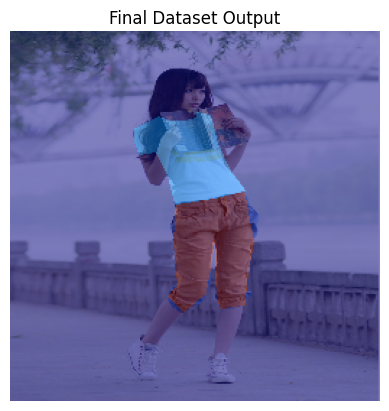

In [17]:
import matplotlib.pyplot as plt

plt.imshow(img.permute(1,2,0))
plt.imshow(mask, alpha=0.5, cmap='jet')
plt.title("Final Dataset Output")
plt.axis("off")

In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Model Training

In [19]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=6   # ⚠️ IMPORTANT (0 + 5 classes)
)

In [20]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [21]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [23]:
!pip install tqdm

from tqdm import tqdm
import matplotlib.pyplot as plt

In [24]:
def compute_iou(pred, mask, num_classes=6):
    ious = []

    pred = pred.view(-1)
    mask = mask.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (mask == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return sum(ious) / len(ious)


def compute_dice(pred, mask, num_classes=6):
    dices = []

    pred = pred.view(-1)
    mask = mask.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (mask == cls)

        intersection = (pred_inds & target_inds).sum().item()

        dice = (2 * intersection) / (pred_inds.sum().item() + target_inds.sum().item() + 1e-6)
        dices.append(dice)

    return sum(dices) / len(dices)

In [25]:
best_val_iou = 0

num_epochs = 10

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    train_iou = 0
    train_dice = 0

    loop = tqdm(train_loader, desc=f"Train Epoch {epoch+1}")

    for images, masks in loop:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # ---- Metrics ----
        preds = torch.argmax(outputs, dim=1)
        train_iou += compute_iou(preds.cpu(), masks.cpu())
        train_dice += compute_dice(preds.cpu(), masks.cpu())

        loop.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)
    avg_train_iou = train_iou / len(train_loader)
    avg_train_dice = train_dice / len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            val_iou += compute_iou(preds.cpu(), masks.cpu())
            val_dice += compute_dice(preds.cpu(), masks.cpu())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    # ================= PRINT =================
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Train IoU: {avg_train_iou:.4f}")
    print(f"Train Dice: {avg_train_dice:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Val IoU: {avg_val_iou:.4f}")
    print(f"Val Dice: {avg_val_dice:.4f}")

    # ================= SAVE BEST MODEL =================
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_iou': avg_val_iou,
            'val_dice': avg_val_dice,
            'val_loss': avg_val_loss
        }, "best_unet.pth")

        print(f"✅ Best model saved at epoch {epoch+1}")

Train Epoch 1: 100%|██████████| 36044/36044 [47:43<00:00, 12.59it/s, loss=0.211]  



Epoch 1/10
Train Loss: 0.4840
Train IoU: 0.3438
Train Dice: 0.4008
Val Loss: 0.3892
Val IoU: 0.4259
Val Dice: 0.4764
✅ Best model saved at epoch 1


Train Epoch 2: 100%|██████████| 36044/36044 [46:39<00:00, 12.88it/s, loss=0.22]  



Epoch 2/10
Train Loss: 0.3351
Train IoU: 0.4762
Train Dice: 0.5285
Val Loss: 0.3277
Val IoU: 0.5120
Val Dice: 0.5320
✅ Best model saved at epoch 2


Train Epoch 3: 100%|██████████| 36044/36044 [46:42<00:00, 12.86it/s, loss=0.211] 


...


Epoch 8/10
Train Loss: 0.1740
Train IoU: 0.6638
Train Dice: 0.6428
Val Loss: 0.2562
Val IoU: 0.6143
Val Dice: 0.6007
✅ Best model saved at epoch 8


Train Epoch 9: 100%|██████████| 36044/36044 [46:45<00:00, 12.85it/s, loss=0.236] 



Epoch 9/10
Train Loss: 0.1593
Train IoU: 0.6803
Train Dice: 0.6520
Val Loss: 0.2509
Val IoU: 0.6252
Val Dice: 0.6101
✅ Best model saved at epoch 9


Train Epoch 10: 100%|██████████| 36044/36044 [46:41<00:00, 12.87it/s, loss=0.115] 



Epoch 10/10
Train Loss: 0.1463
Train IoU: 0.6963
Train Dice: 0.6617
Val Loss: 0.2628
Val IoU: 0.6274
Val Dice: 0.6016
✅ Best model saved at epoch 10
